In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('DADOS.csv', parse_dates=True, index_col='Timestamp')

In [31]:
df

,Umidade,Temp1,Temp2
Timestamp,,,
2025-11-24 18:53:43,68.0,20.53,20.07
2025-11-24 18:58:45,64.0,20.04,21.05
2025-11-24 19:03:47,63.0,20.53,20.07
2025-11-24 19:08:49,62.0,20.53,20.07
2025-11-24 19:13:51,56.0,20.53,20.07
...,...,...,...
2025-12-11 14:50:48,21.0,31.77,33.76
2025-12-11 14:55:50,21.0,32.75,34.74
2025-12-11 15:00:51,20.0,33.24,35.22


In [32]:
terca_25 = df['2025-11-25':'2025-11-25']
quarta_26 = df['2025-11-26':'2025-11-26']
quinta_27 = df['2025-11-27':'2025-11-27']
sexta_28 = df['2025-11-28':'2025-11-28']
domingo_30 = df['2025-11-30':'2025-11-30']
segunda_01 = df['2025-12-01':'2025-12-01']
terca_02 = df['2025-12-02':'2025-12-02']
quarta_03 = df['2025-12-03':'2025-12-03']
quinta_04 = df['2025-12-04':'2025-12-04']
sexta_05 = df['2025-12-05':'2025-12-05']
sabado_06 = df['2025-12-06':'2025-12-06']
domingo_07 = df['2025-12-07':'2025-12-07']
segunda_08 = df['2025-12-08':'2025-12-08']
terca_09 = df['2025-12-09':'2025-12-09']
quarta_10 = df['2025-12-10':'2025-12-10']
quinta_11 = df['2025-12-11':'2025-12-11']


In [33]:
dias = [terca_25, quarta_26, quinta_27, sexta_28, domingo_30, segunda_01, terca_02, quarta_03, quinta_04, sexta_05, sabado_06, domingo_07, segunda_08, terca_09, quarta_10]

In [34]:
dias[0].index[0].strftime("%d/%m")

'25/11'

In [35]:
for i, d in enumerate(dias):
    print(i, len(d))


0 287
1 282
2 287
3 288
4 288
5 286
6 258
7 285
8 284
9 201
10 288
11 287
12 274
13 285
14 287


In [36]:
def day_hour_series(day):
  return day.index.hour + day.index.minute/60 + day.index.second/3600

In [37]:
def avg_30min(df_day):
    """
    Return a new DataFrame resampled to 30-minute averages.
    Missing intervals are filled with NaN.
    """
    return (
        df_day
        .resample('30min')
        .mean()
    )


In [38]:
def avg_1h(df_day):
    """
    Return a new DataFrame resampled to 1-hour averages.
    Missing intervals are filled with NaN.
    """
    return (
        df_day
        .resample('1h')
        .mean()
    )


In [39]:
plt.style.use("plotstyle.mplstyle")

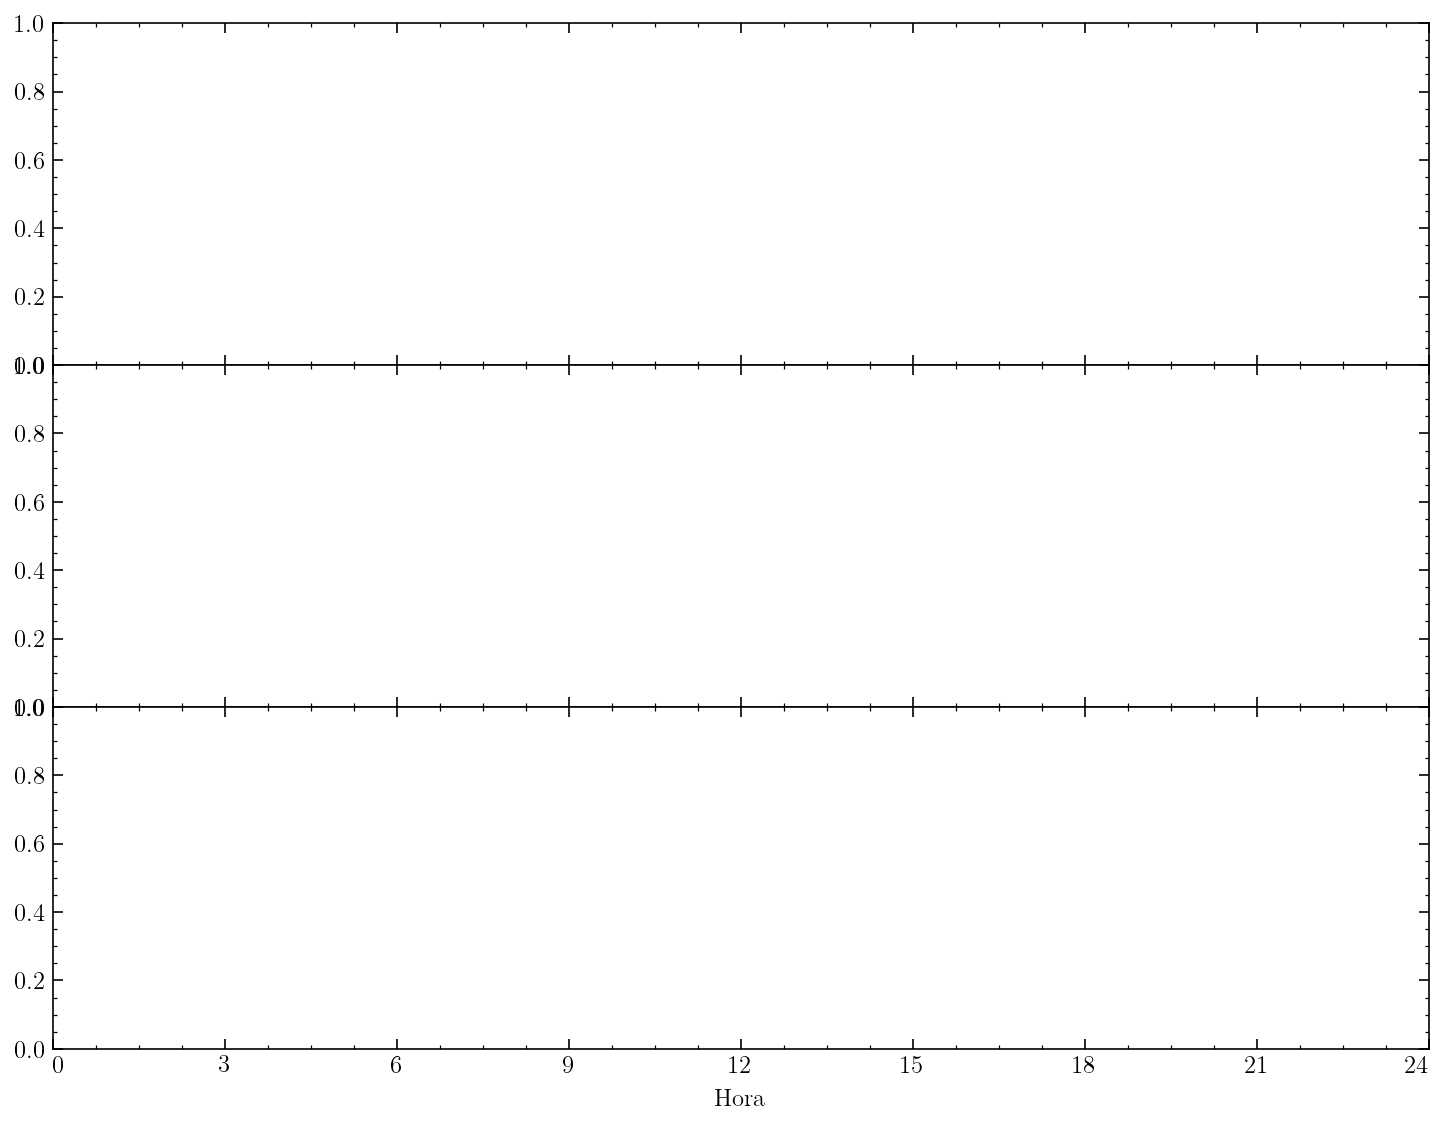

In [40]:
#Figura com 3 subplots colados, verticalmente

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

#set row separation to 0

fig.subplots_adjust(hspace=0)

ax[2].set_xlim(0, 24)
ax[2].set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 24])
ax[2].set_xlabel("Hora")

ax[2].get_xticklabels()[0].set_horizontalalignment("left")
ax[2].get_xticklabels()[-1].set_horizontalalignment("right")


In [41]:
day = quinta_27

In [42]:
hours = np.arange(0.5, 24.5, 0.5)

In [43]:
ax[0].set_title(f"Médias móveis de 30 minutos - " + day.index[0].strftime('%d/%m/%Y'))
ax[0].plot(hours, avg_30min(day).Umidade, label="Média móvel umidade", c="red", marker="o", lw=2)
ax[0].grid(True, alpha=0.5)
ax[0].set_ylabel("Umidade (\%)")
ax[0].set_ylim(20, 100)
ax[0].get_yticklabels()[0].set_verticalalignment("bottom")
ax[0].get_yticklabels()[-1].set_verticalalignment("top")
ax[0].legend()

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_36154/1323674610.py:4: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_ylabel("Umidade (\%)")


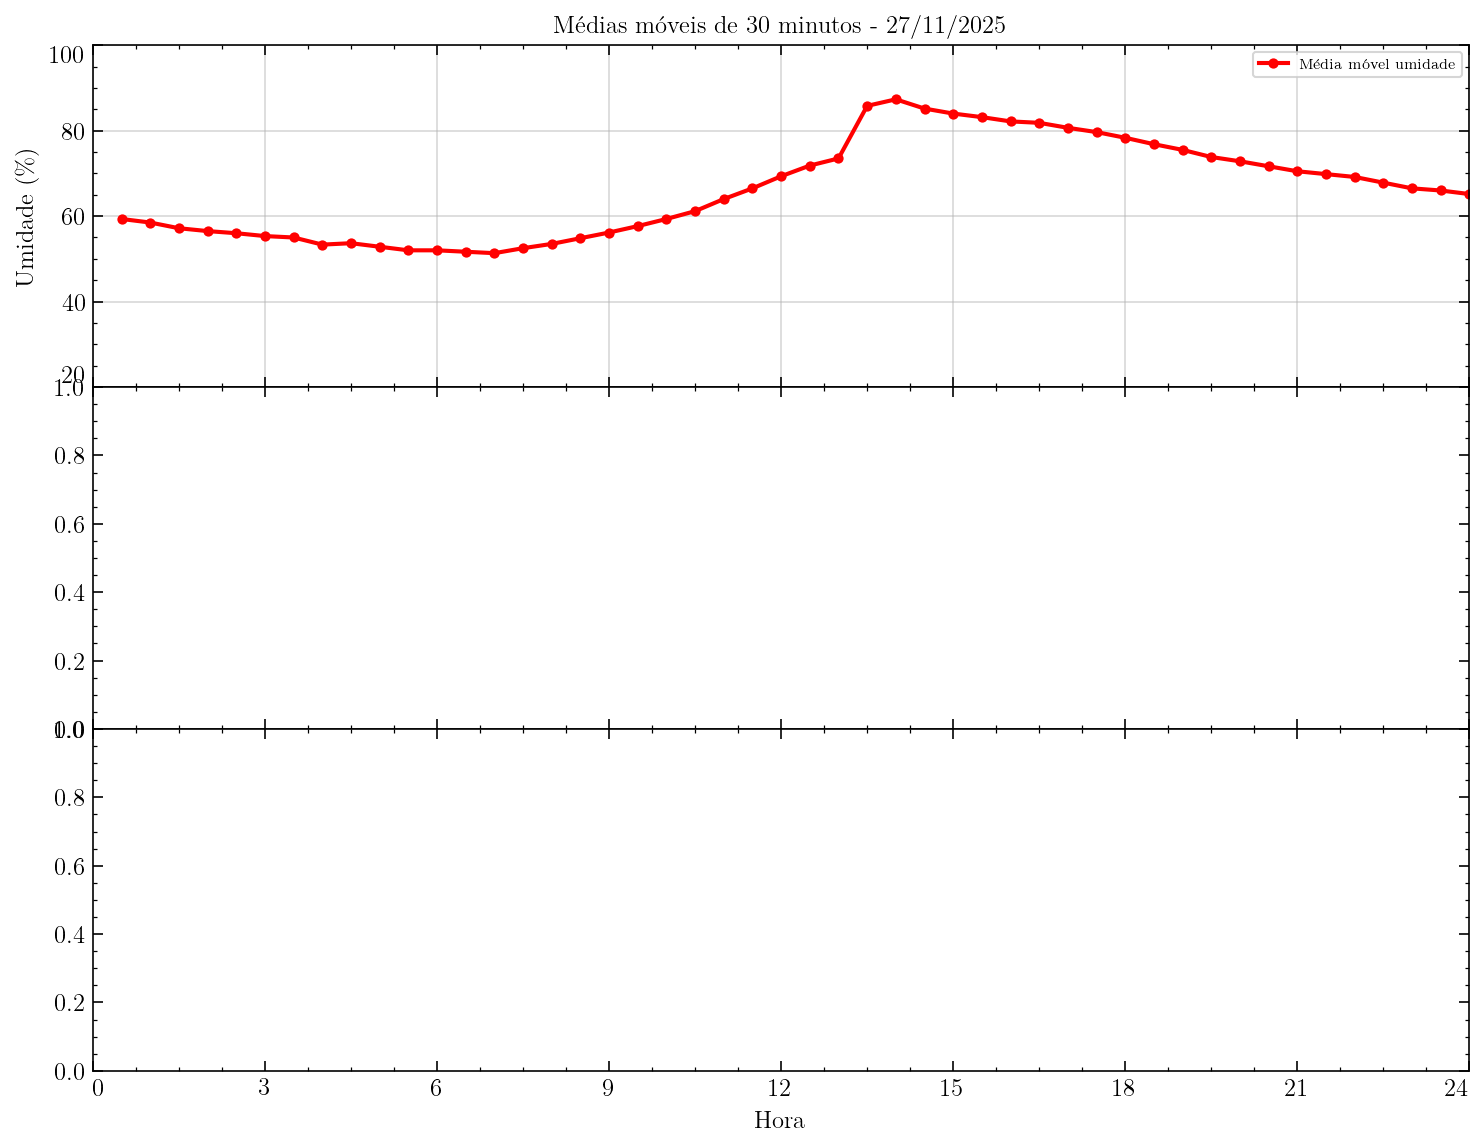

In [44]:
fig

In [45]:
ax[1].plot(hours, avg_30min(day).Temp1, label="Média móvel Telhado Verde", c="green", marker="o", lw=2)
ax[1].plot(hours, avg_30min(day).Temp2, label="Média móvel Telhado Azul", c="blue", marker="X", lw=2)
ax[1].grid(True, alpha=0.5)
ax[1].set_ylabel("Temperatura (ºC)")
ax[1].set_ylim(10, 40)
ax[1].get_yticklabels()[0].set_verticalalignment("bottom")
ax[1].get_yticklabels()[-1].set_verticalalignment("top")
ax[1].legend()

In [46]:
ax[2].plot(hours, avg_30min(day).Temp2-avg_30min(day).Temp1,label="Azul-Verde", c="orange", marker="o", lw=2)
ax[2].grid(True, alpha=0.5)
ax[2].set_ylabel("Temperatura (ºC)")
ax[2].set_ylim(-6, 6)
ax[2].get_yticklabels()[0].set_verticalalignment("bottom")
ax[2].get_yticklabels()[-1].set_verticalalignment("top")
ax[2].axhline(y=0, color="black", linestyle="--")
ax[2].legend()

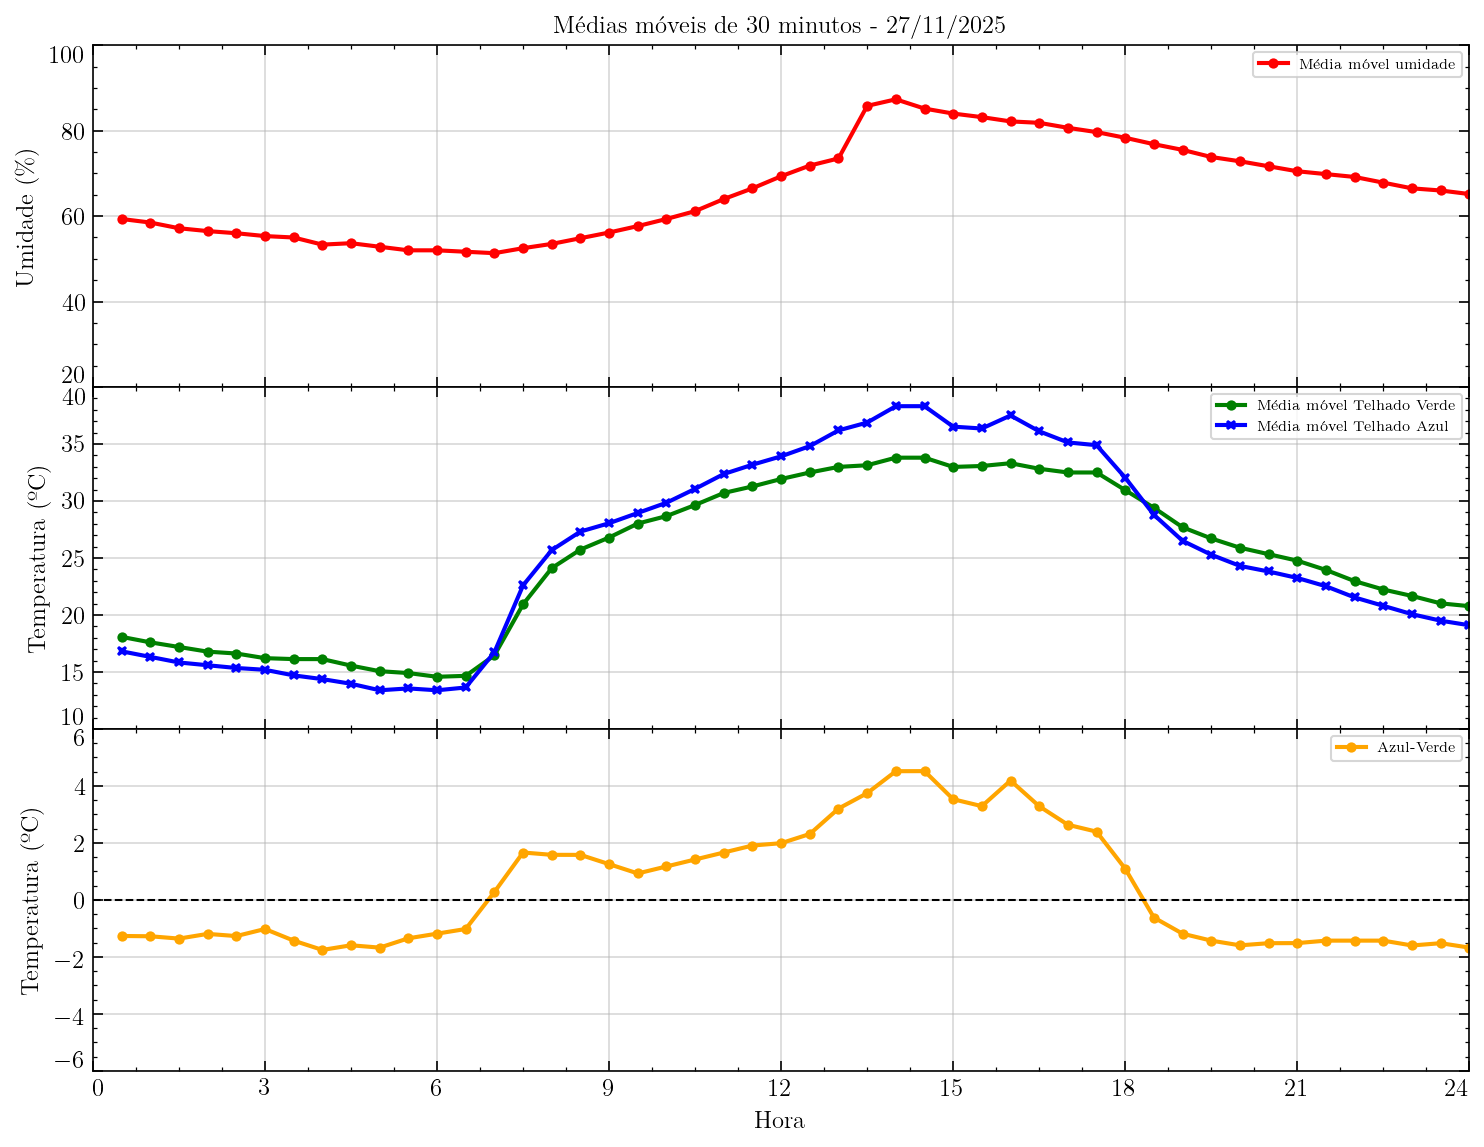

In [47]:
fig.savefig("medias_moveis_telhados.png", dpi=300)
fig

In [48]:
means=np.zeros((len(dias), 24))
names = []
for i in range(len(dias)):
  day_name = dias[i].index[0].strftime("%d/%m")
  names.append(day_name)

  means[i] = avg_1h(dias[i]).Temp2 - avg_1h(dias[i]).Temp1



In [49]:
means

array([[-5.31666667e-01, -4.60000000e-01, -4.60000000e-01,
        -5.00833333e-01, -5.00833333e-01, -7.86666667e-01,
        -5.00000000e-02,  4.04166667e-01,  3.16666667e-02,
         6.90833333e-01,  1.74416667e+00,  2.15083333e+00,
         1.78666667e+00,  2.07083333e+00,  3.86166667e+00,
         2.92416667e+00,  2.88416667e+00,  1.05166667e+00,
        -7.40000000e-01, -1.38916667e+00, -1.61090909e+00,
        -1.19416667e+00, -1.22666667e+00, -1.02166667e+00],
       [-9.43333333e-01, -1.15416667e+00, -7.85000000e-01,
        -8.58333333e-01, -9.80833333e-01, -1.47083333e+00,
        -6.15833333e-01,  1.21500000e+00,  2.79166667e-01,
         3.56666667e-01,  1.77000000e-01,  1.18909091e+00,
         1.94916667e+00,  2.76583333e+00,  3.50900000e+00,
         4.18666667e+00,  3.17416667e+00,  1.58000000e+00,
        -1.34454545e+00, -1.88000000e+00, -1.47083333e+00,
        -1.19333333e+00, -1.34833333e+00, -1.22583333e+00],
       [-1.27166667e+00, -1.27583333e+00, -1.14583333e

In [50]:
np.where(means == means.min())[1]

array([], dtype=int64)

In [51]:
names[3]

'28/11'

In [52]:
range(25)[22]

22

In [53]:
names

['25/11',
 '26/11',
 '27/11',
 '28/11',
 '30/11',
 '01/12',
 '02/12',
 '03/12',
 '04/12',
 '05/12',
 '06/12',
 '07/12',
 '08/12',
 '09/12',
 '10/12']

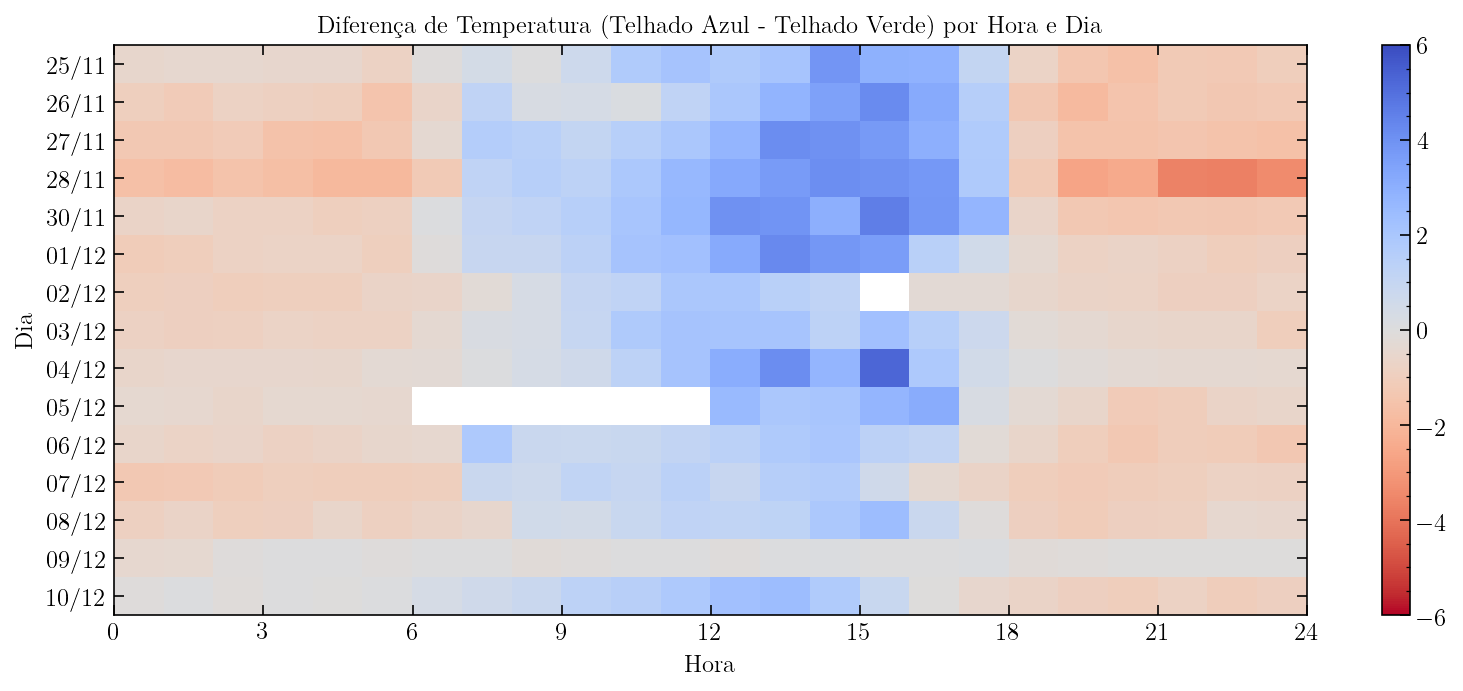

In [54]:
x = np.arange(24)
y = np.arange(len(dias))

fig, ax = plt.subplots(figsize=(13, 5))

ax.set_title("Diferença de Temperatura (Telhado Azul - Telhado Verde) por Hora e Dia")

c = ax.imshow(means, cmap='coolwarm_r', vmin=-6, vmax=6,
              extent=[0, 24, 0, len(dias)], aspect='auto')

#ax.text(np.where(means == means.min())[1]+0.5, np.where(means == means.min())[0]-0.5, str(round(means.min(), 2)), ha="center", va="center", color="black", fontsize=5, rotation=90)
#ax.text(np.where(means == means.max())[1]+0.5, np.where(means == means.max())[0]-2.5, str(round(means.max(), 2)), ha="center", va="center", color="black", fontsize=5, rotation=90)




#set tick labels
ax.set_xlabel("Hora")
ax.set_ylabel("Dia")
ax.set_xticks(np.arange(0, 25, 3))
ax.set_yticks(np.arange(len(dias))+0.5)
ax.set_yticklabels(names[::-1])
#remove minor ticks

ax.tick_params(axis='both', which='minor', length=0)
fig.colorbar(c, ax=ax)

fig.savefig("heatmap_diferenca_temperaturas_telhados.png", dpi=300)

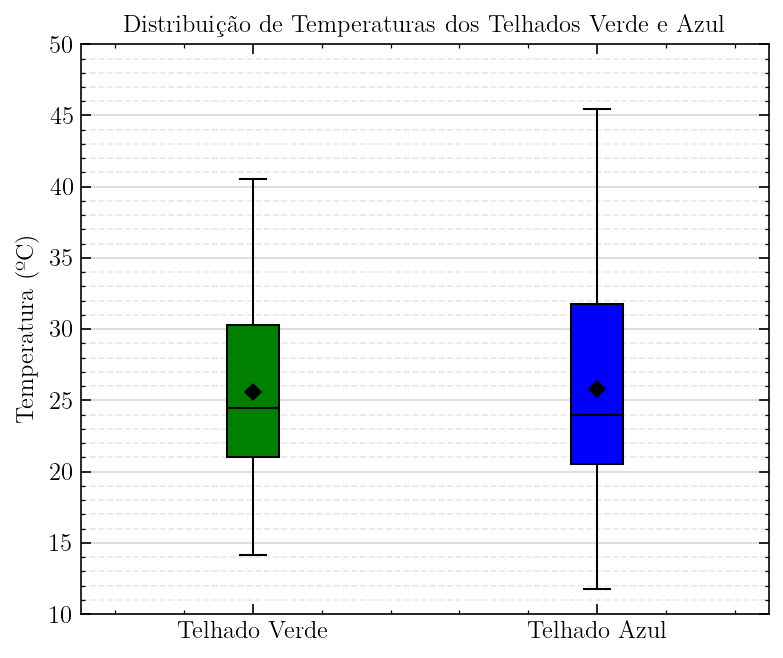

In [55]:
temperatures = [df['Temp1'], df['Temp2']]
labels = ['Telhado Verde', 'Telhado Azul']

fig, ax = plt.subplots(figsize=(6, 5))
bplot = ax.boxplot(temperatures, tick_labels=labels, patch_artist=True, showmeans=True)
ax.set_title("Distribuição de Temperaturas dos Telhados Verde e Azul")
ax.set_ylabel("Temperatura (ºC)")   
ax.set_ylim(10, 50)
ax.grid(True, axis='y', alpha=0.5)
colors = ['green', 'blue']

#set minor grid lines
ax.yaxis.grid(True, which='minor', linestyle='--', alpha=0.3)

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

for median in bplot['medians']:
    median.set_color('black')

for mean in bplot['means']:
    mean.set_marker('D')
    mean.set_markerfacecolor('black')
    mean.set_markeredgecolor('white')

fig.savefig("boxplot_temperaturas_telhados.png", dpi=300)

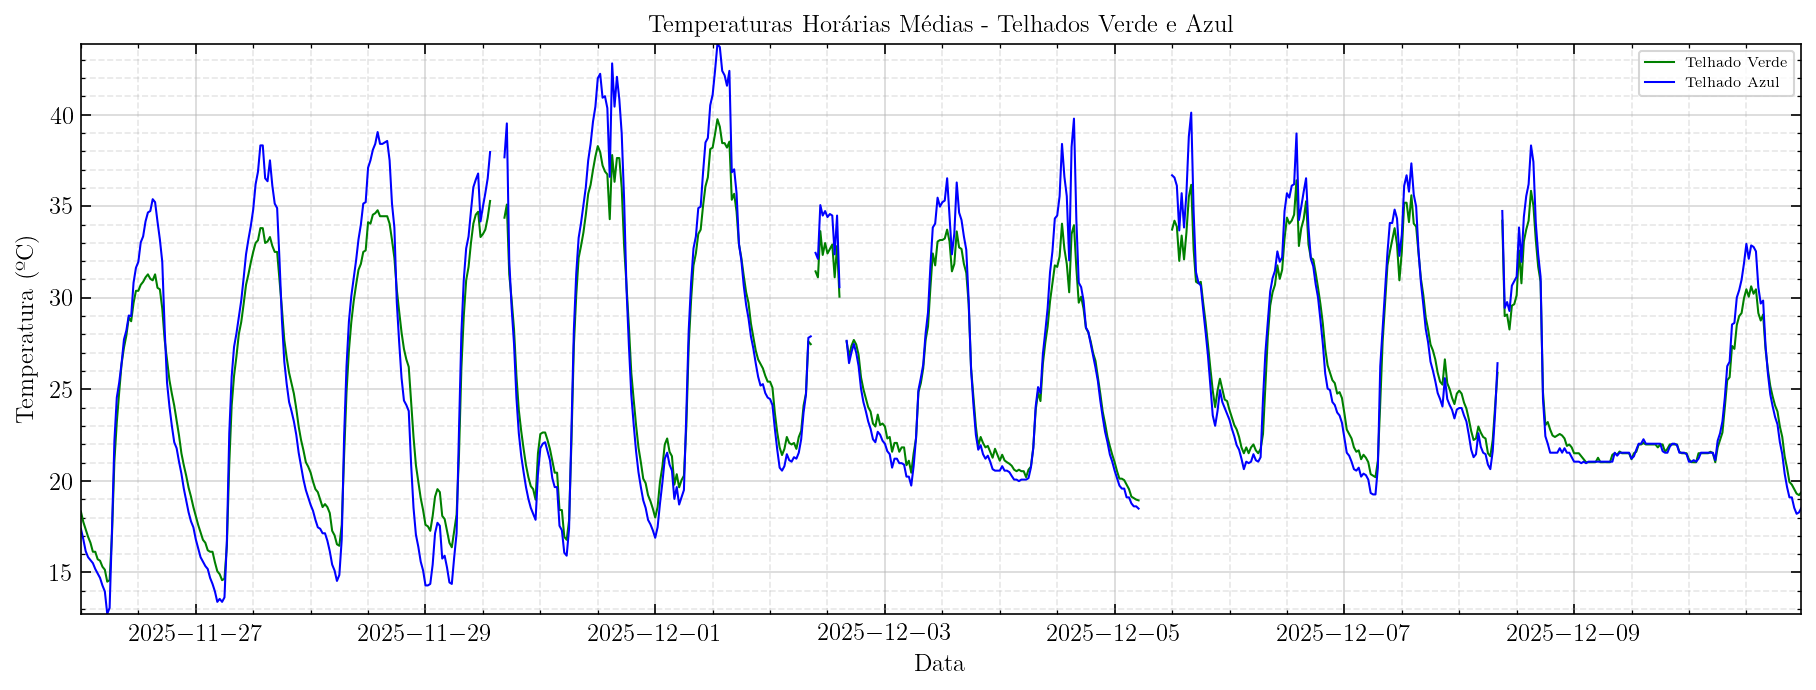

In [57]:
df_avg = df["2025-11-26":"2025-12-10"].resample('30min').mean()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_avg.index, df_avg.Temp1, label="Telhado Verde", c="green", lw=1)
ax.plot(df_avg.index, df_avg.Temp2, label="Telhado Azul", c="blue", lw=1)
ax.set_title("Temperaturas Horárias Médias - Telhados Verde e Azul")
ax.set_ylabel("Temperatura (ºC)")
ax.set_xlabel("Data")
ax.grid(True, alpha=0.5)
ax.grid(which='minor', linestyle='--', alpha=0.3)
ax.legend()

In [63]:
df.Temp1.max()

np.float64(40.57)